In [1]:
import numpy as np
import matplotlib.pyplot as plt

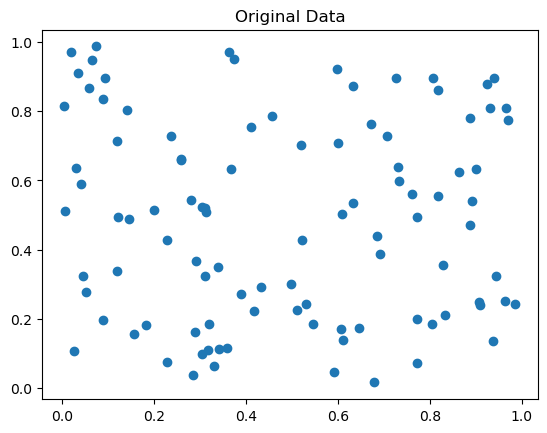

In [2]:
np.random.seed(42)

# generate dataset
X = np.random.rand(100,2)

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

In [3]:
k = 3  # number of clusters

# randomly select medoids
medoid_indices = np.random.choice(len(X), k, replace=False)
medoids = X[medoid_indices]

for iteration in range(100):

    # compute distances from points to medoids
    distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)

    # assign clusters
    labels = np.argmin(distances, axis=1)

    new_medoids = []

    # update medoids
    for i in range(k):
        cluster_points = X[labels == i]

        if len(cluster_points) == 0:
            new_medoids.append(medoids[i])
            continue

        # compute total distance for each point in cluster
        costs = []
        for point in cluster_points:
            cost = np.sum(np.linalg.norm(cluster_points - point, axis=1))
            costs.append(cost)

        new_medoid = cluster_points[np.argmin(costs)]
        new_medoids.append(new_medoid)

    new_medoids = np.array(new_medoids)

    if np.all(medoids == new_medoids):
        break

    medoids = new_medoids

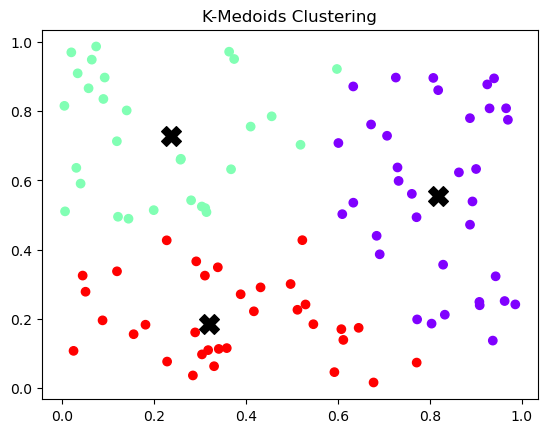

In [4]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.scatter(medoids[:,0], medoids[:,1], c='black', marker='X', s=200)
plt.title("K-Medoids Clustering")
plt.show()